In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
DATASET_FOLDER = "/content/drive/MyDrive/Dataset (1)"
print("Dataset folder exists:", os.path.exists(DATASET_FOLDER))
print("\nInside Dataset (1):")
print(os.listdir(DATASET_FOLDER))

Dataset folder exists: True

Inside Dataset (1):
['DIATAquarium.v4i.yolov8', 'Aquatic Plant.v2i.yolov8', 'well.v8i.yolov8']


In [ ]:
import os
DATASETS = [
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"]
for dataset in DATASETS:
    path = os.path.join(DATASET_FOLDER, dataset)
    print()
    print(dataset)
    print()
    print(os.listdir(path))


DIATAquarium.v4i.yolov8

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'train', 'valid']

Aquatic Plant.v2i.yolov8

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'train', 'valid', 'test']

well.v8i.yolov8

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'valid', 'test', 'train']


In [ ]:
import os
for dataset in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset)
    print()
    print(dataset)
    print()
    for split in ["train", "valid", "test"]:
        split_path = os.path.join(dataset_path, split)

        if not os.path.exists(split_path):
            print(f"\n{split}: NOT PRESENT")
            continue

        print(f"\n{split}:")
        print(os.listdir(split_path))


DIATAquarium.v4i.yolov8


train:
['labels.cache', 'labels', 'images']

valid:
['labels.cache', 'labels', 'images']

test: NOT PRESENT

Aquatic Plant.v2i.yolov8


train:
['labels.cache', 'labels', 'images']

valid:
['labels.cache', 'labels', 'images']

test:
['images', 'labels']

well.v8i.yolov8


train:
['labels.cache', 'labels.cache.npy', 'labels', 'images']

valid:
['labels.cache', 'labels.cache.npy', 'images', 'labels']

test:
['labels.cache', 'labels', 'images']


In [ ]:
import os
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")
def count_files(folder, extensions):
    if not os.path.exists(folder):
        return 0
    return sum(1
        for file in os.listdir(folder)
        if file.lower().endswith(extensions))

for dataset in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset)
    print()
    print(dataset)
    print()
    for split in ["train", "valid", "test"]:
        split_path = os.path.join(dataset_path, split)
        if not os.path.exists(split_path):
            print(f"\n{split}: NOT PRESENT")
            continue
        image_path = os.path.join(split_path, "images")
        label_path = os.path.join(split_path, "labels")
        image_count = count_files(image_path,IMAGE_EXTENSIONS)
        label_count = count_files(label_path,(".txt",))
        print(f"\n{split}:")
        print(f"  Images: {image_count}")
        print(f"  Labels: {label_count}")


DIATAquarium.v4i.yolov8


train:
  Images: 8121
  Labels: 8121

valid:
  Images: 773
  Labels: 773

test: NOT PRESENT

Aquatic Plant.v2i.yolov8


train:
  Images: 1892
  Labels: 1879

valid:
  Images: 179
  Labels: 179

test:
  Images: 89
  Labels: 89

well.v8i.yolov8


train:
  Images: 3795
  Labels: 3780

valid:
  Images: 191
  Labels: 191

test:
  Images: 184
  Labels: 184


In [ ]:
import os
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
def get_image_names(folder):
    if not os.path.exists(folder):
        return set()
    return {
        os.path.splitext(file)[0]
        for file in os.listdir(folder)
        if file.lower().endswith(IMAGE_EXTENSIONS)
    }
def get_label_names(folder):
    if not os.path.exists(folder):
        return set()
    return {
        os.path.splitext(file)[0]
        for file in os.listdir(folder)
        if file.lower().endswith(".txt")
    }

for dataset in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset)
    print()
    print(dataset)
    print()
    for split in ["train", "valid", "test"]:
        split_path = os.path.join(dataset_path, split)
        if not os.path.exists(split_path):
            print(f"\n{split}: NOT PRESENT")
            continue
        image_path = os.path.join(split_path, "images")
        label_path = os.path.join(split_path, "labels")
        images = get_image_names(image_path)
        labels = get_label_names(label_path)
        images_without_labels = images - labels
        labels_without_images = labels - images
        print(f"\n{split}:")
        print("Images without matching label:", len(images_without_labels))
        print("Labels without matching image:", len(labels_without_images))
        if images_without_labels:
            print("Example images without labels:")
            print(list(images_without_labels)[:10])
        if labels_without_images:
            print("Example labels without images:")
            print(list(labels_without_images)[:10])


DIATAquarium.v4i.yolov8


train:
Images without matching label: 0
Labels without matching image: 0

valid:
Images without matching label: 0
Labels without matching image: 0

test: NOT PRESENT

Aquatic Plant.v2i.yolov8


train:
Images without matching label: 13
Labels without matching image: 0
Example images without labels:
['2023-12-09_13_20_33_mp4-233_jpg.rf.7ca107fdfd85a019e403ef47e9633954 (1)', '2023-12-09_13_20_33_mp4-22_jpg.rf.61c0d893d08aac31dc21eaf30006a0c5 (1)', '2023-12-09_13_20_33_mp4-22_jpg.rf.a38e81979d73c58328643c40f36cf868 (1)', '2023-12-09_13_20_33_mp4-232_jpg.rf.9b52847ee167eea054e5d64e0472f06b (1)', '2023-12-09_13_20_33_mp4-232_jpg.rf.a917262169c6b8b9c35c0d90fce4141b (1)', '2023-12-09_13_20_33_mp4-233_jpg.rf.546364ee83c3ea56f1fa5d654c9be0f4 (1)', '2023-12-09_13_20_33_mp4-22_jpg.rf.e49ef306b2cd55aeae2bddcc27202fa0 (1)', '2023-12-09_13_20_33_mp4-231_jpg.rf.06eb8e5c8b7aac3cc84d70ddb7e2328c (1)', '2023-12-09_13_20_33_mp4-234_jpg.rf.25958bd03e7fe614cba43c2fc7490fc6 (1)', '

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
def show_images_without_labels(dataset_name, split="train", number=10):
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    image_path = os.path.join(dataset_path, split, "images")
    label_path = os.path.join(dataset_path, split, "labels")
    image_names = {
        os.path.splitext(file)[0]
        for file in os.listdir(image_path)
        if file.lower().endswith(IMAGE_EXTENSIONS)}
    label_names = {
        os.path.splitext(file)[0]
        for file in os.listdir(label_path)
        if file.lower().endswith(".txt")}
    missing_labels = list(image_names - label_names)
    print("Dataset:", dataset_name)
    print("Split:", split)
    print("Images without labels:", len(missing_labels))
    for image_name in missing_labels[:number]:
        matching_files = [
            file for file in os.listdir(image_path)
            if os.path.splitext(file)[0] == image_name
        ]
        if not matching_files:
            continue
        filename = matching_files[0]
        filepath = os.path.join(image_path, filename)
        try:
            img = Image.open(filepath)
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(filename)
            plt.axis("off")
            plt.show()
        except Exception as e:
            print("Could not open:", filename, e)

Dataset: Aquatic Plant.v2i.yolov8
Split: train
Images without labels: 13


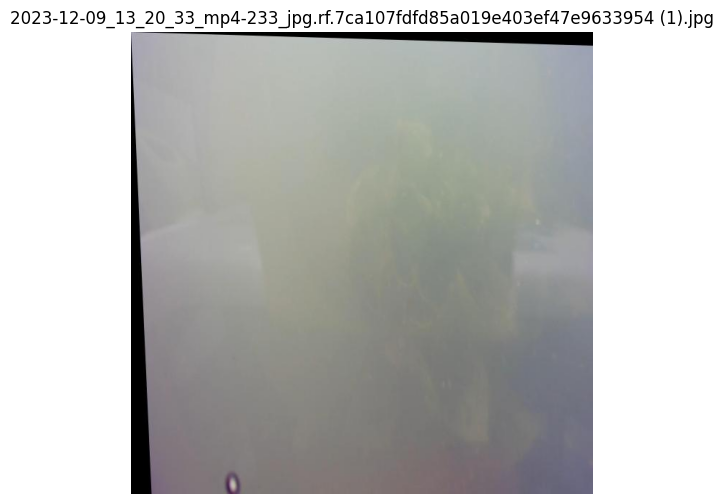

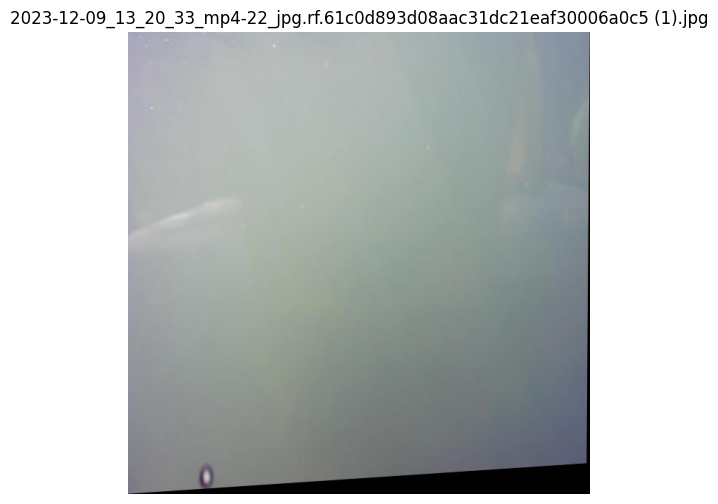

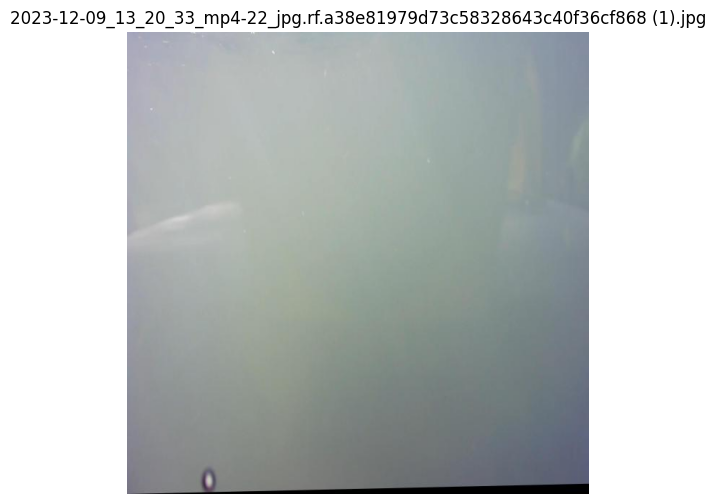

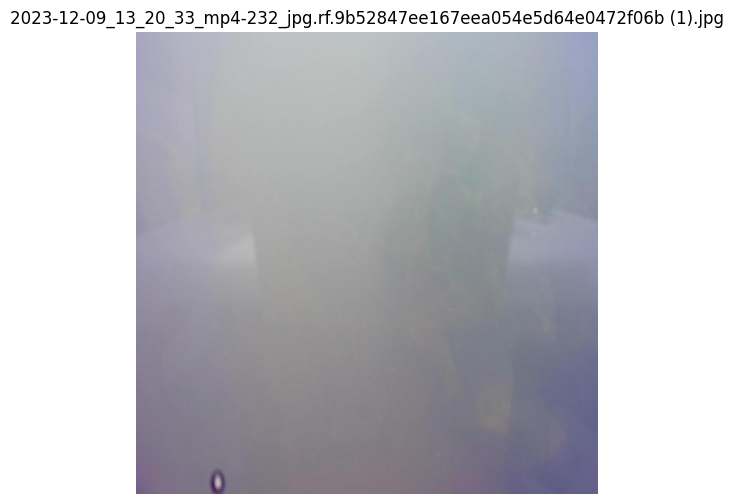

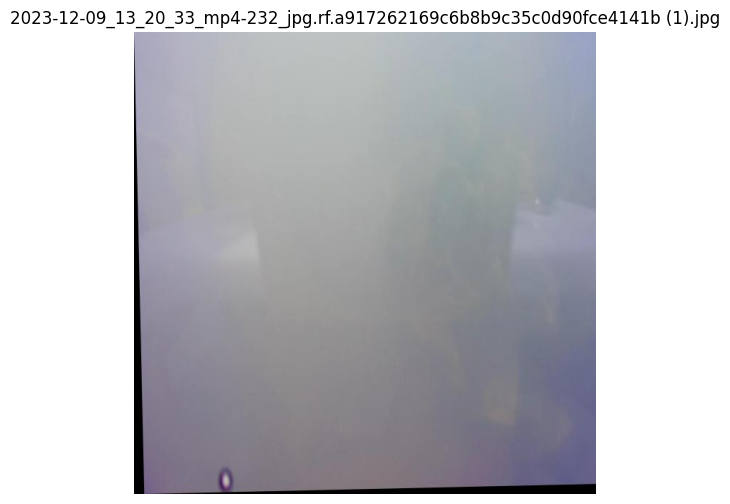

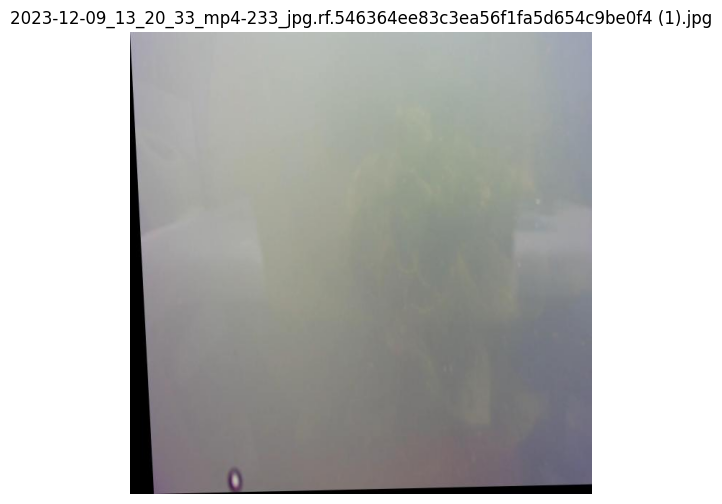

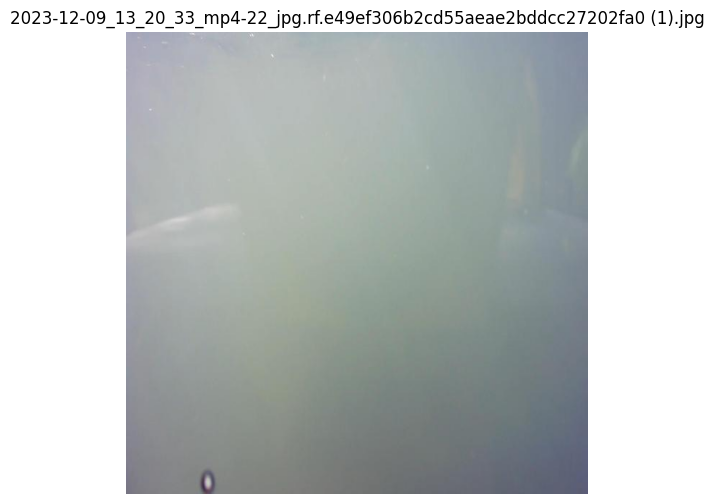

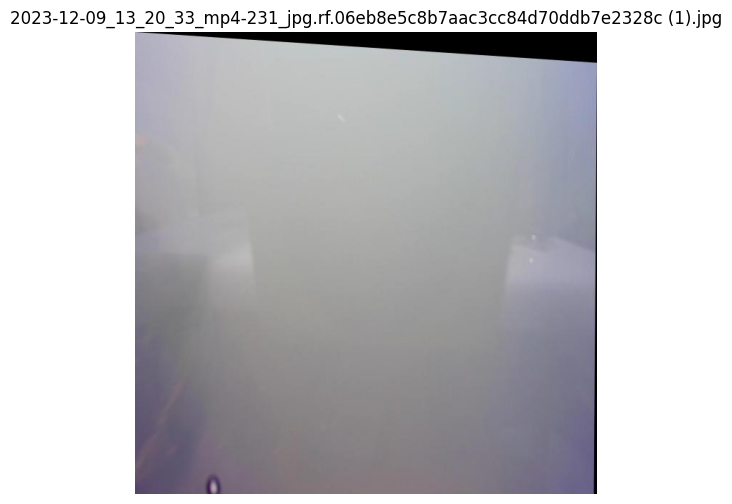

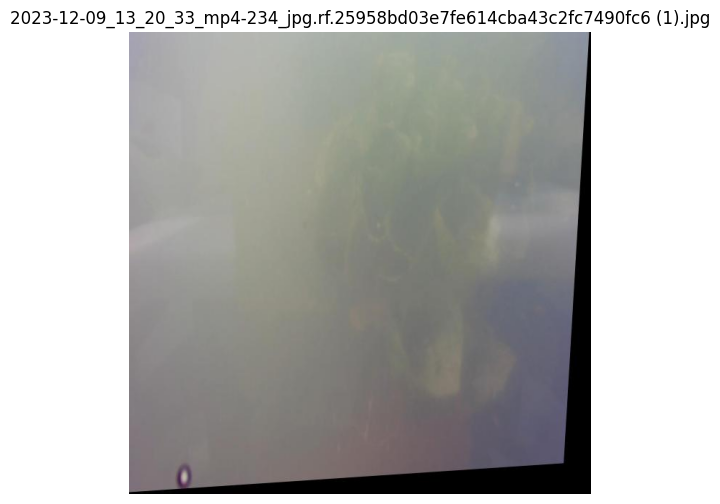

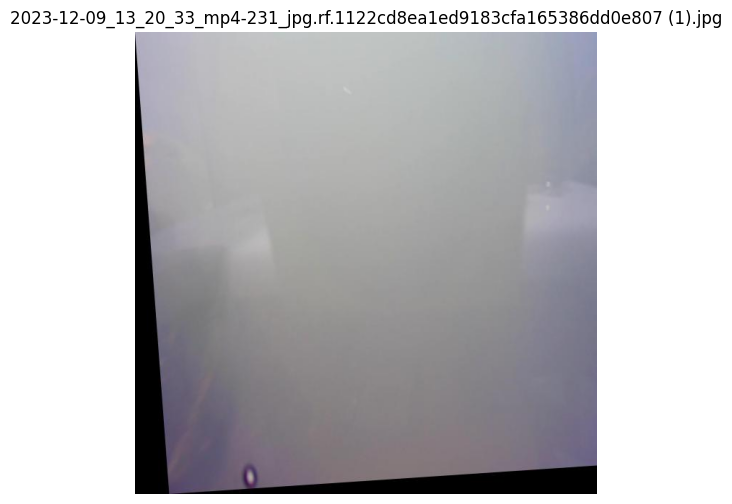


Dataset: well.v8i.yolov8
Split: train
Images without labels: 15


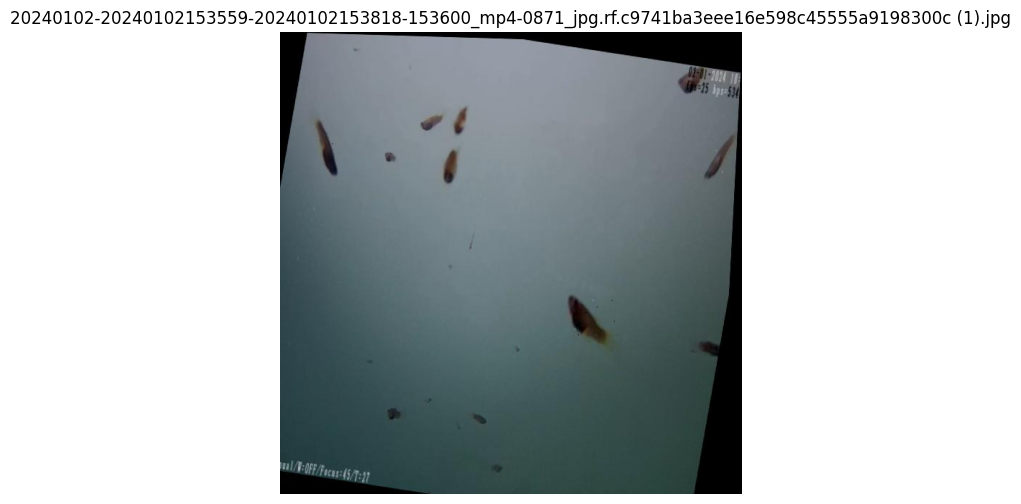

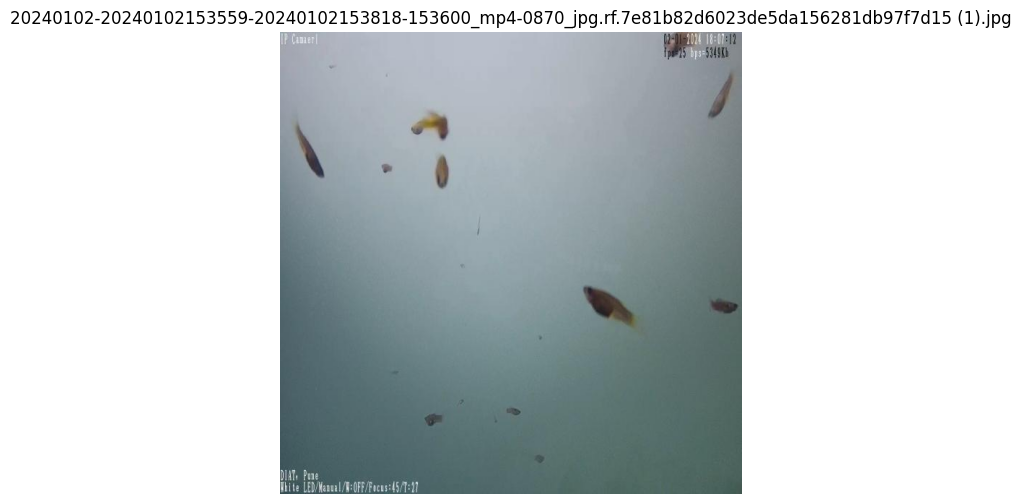

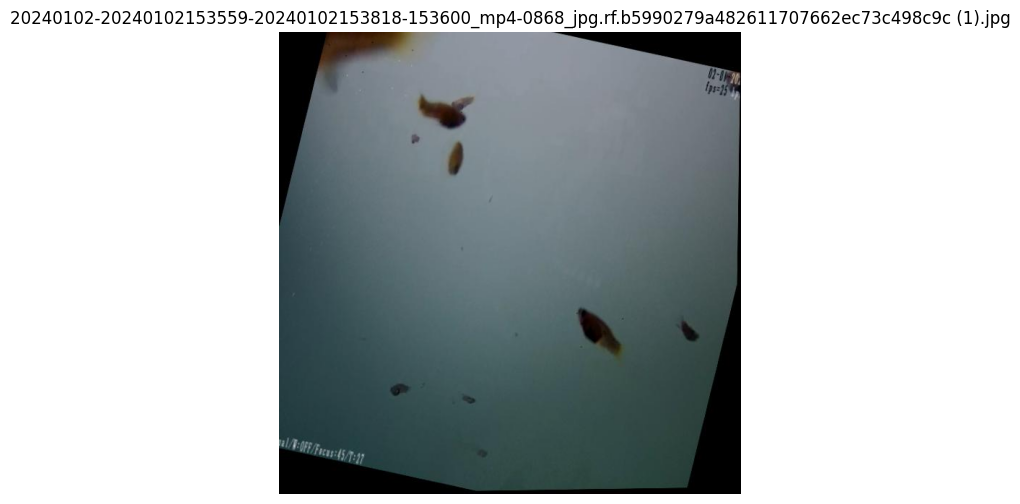

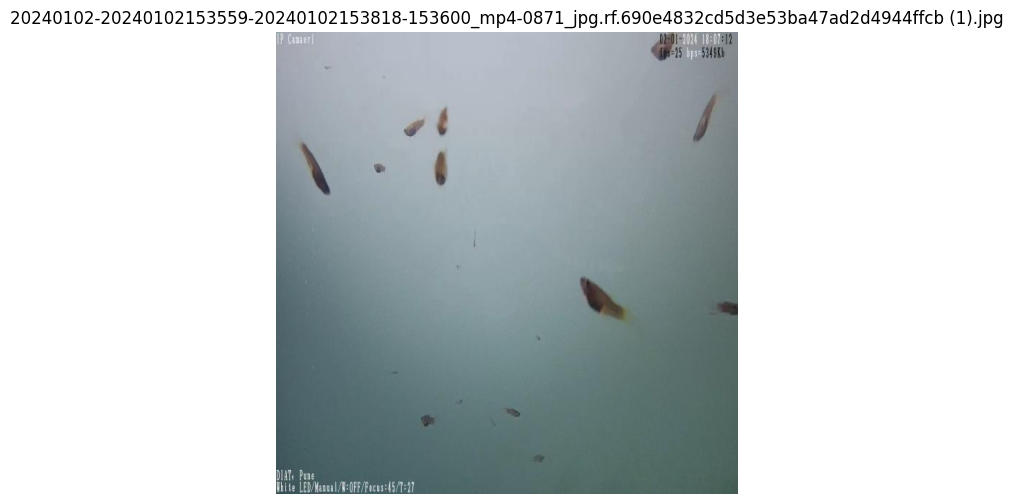

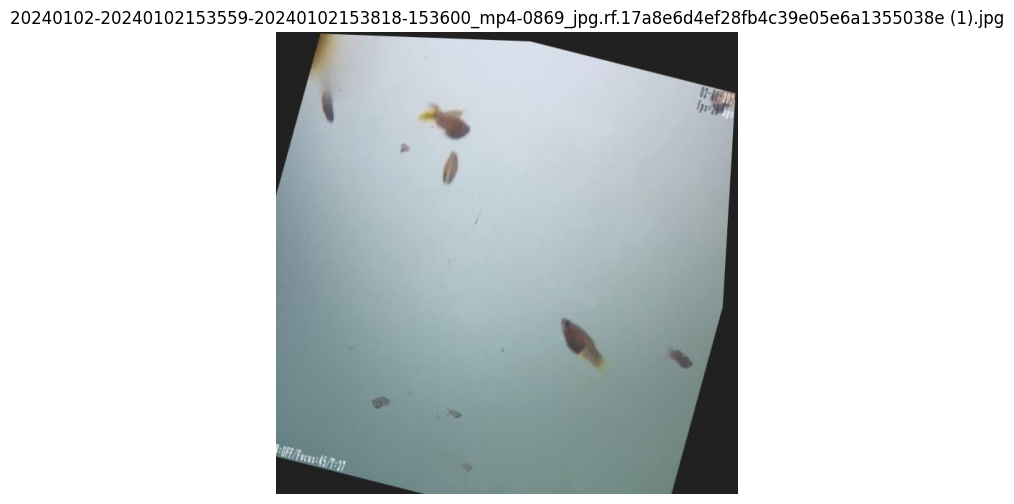

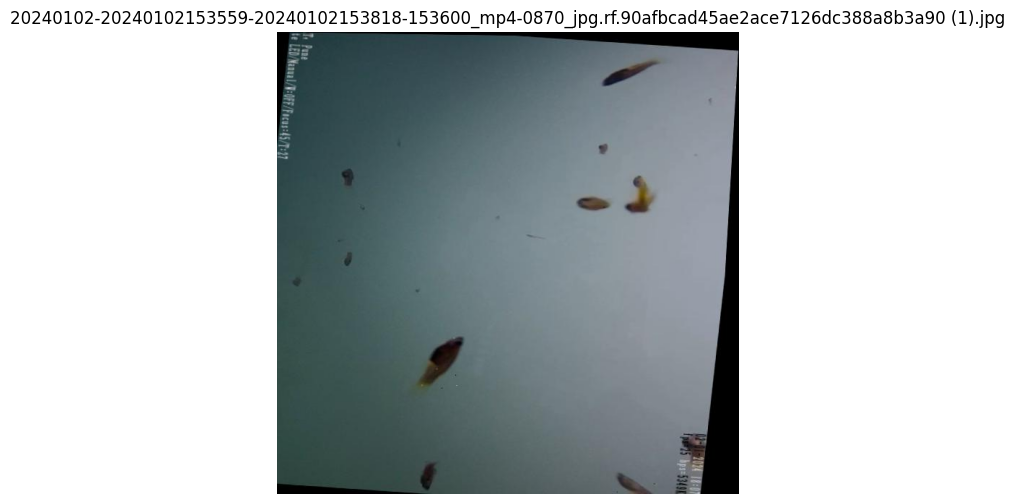

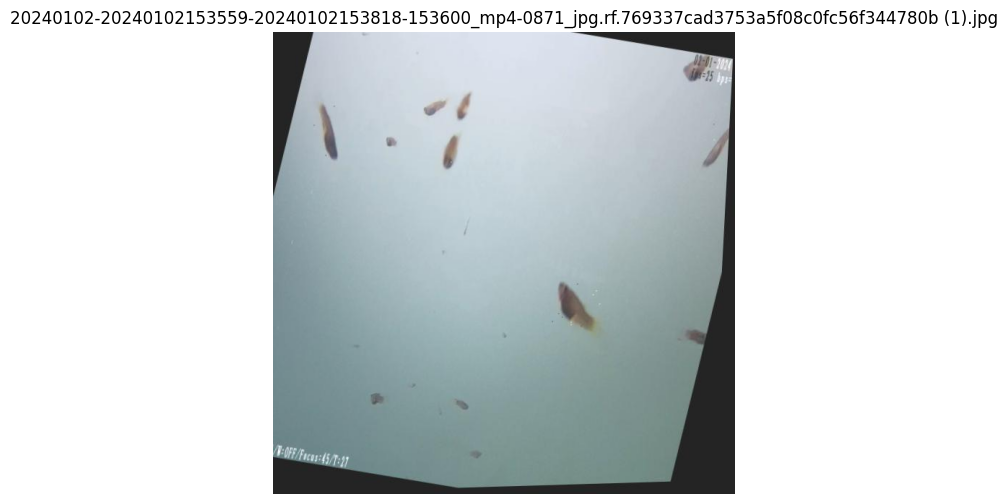

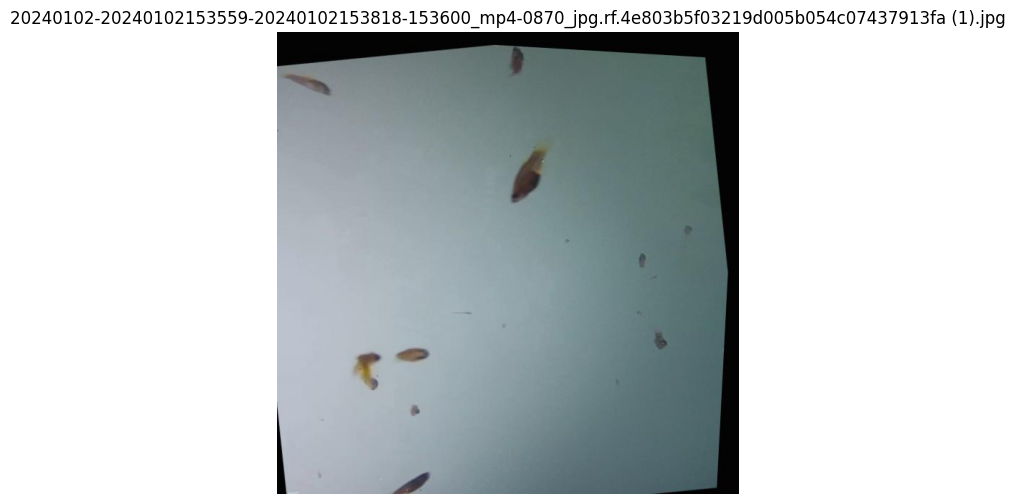

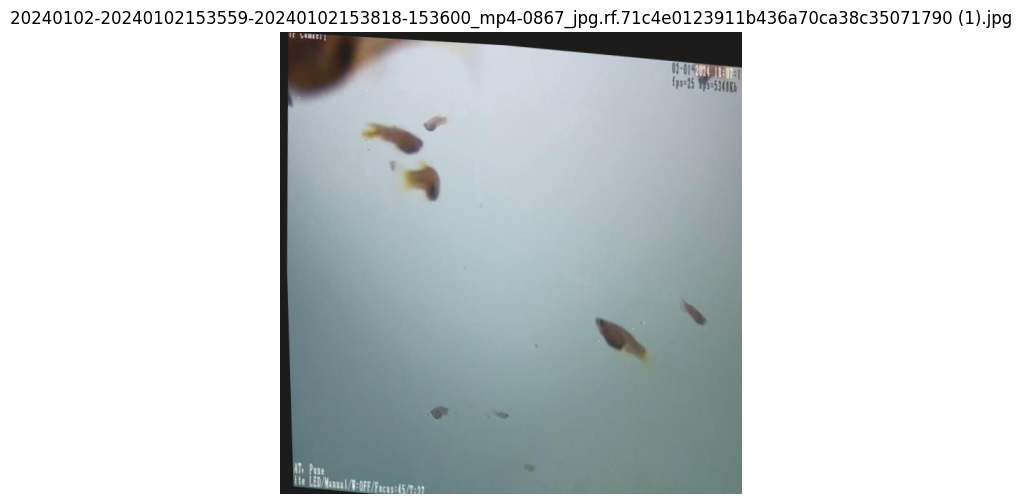

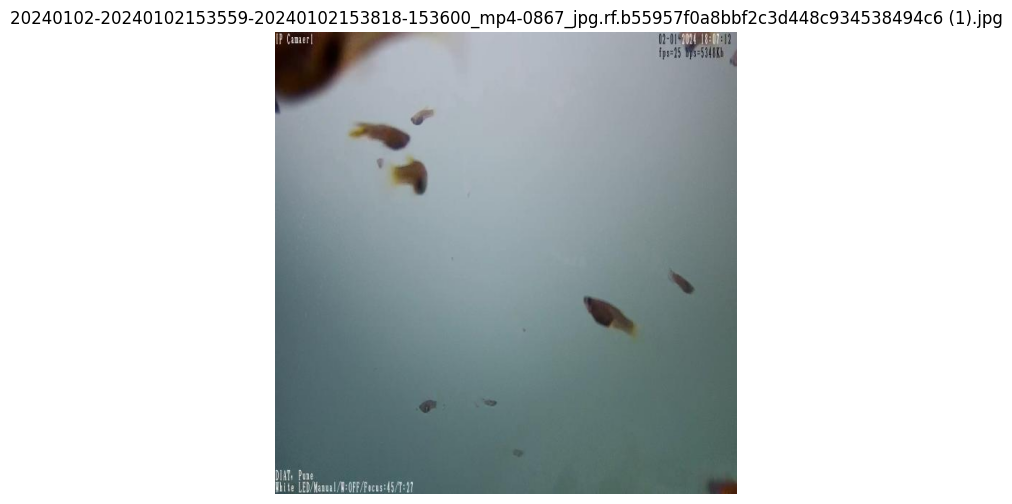


Dataset: DIATAquarium.v4i.yolov8
Split: train
Images without labels: 0


In [ ]:
show_images_without_labels("Aquatic Plant.v2i.yolov8","train",10)
print()
show_images_without_labels("well.v8i.yolov8","train",10)
print()
show_images_without_labels("DIATAquarium.v4i.yolov8","train",10)

In [ ]:
import os
def check_yolo_labels(dataset_name):
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    yaml_path = os.path.join(dataset_path, "data.yaml")
    class_names = None
    if os.path.exists(yaml_path):
        with open(yaml_path, "r", encoding="utf-8") as f:
            yaml_text = f.read()
        print("data.yaml found")
        print(yaml_text)
    print()
    print("Dataset:", dataset_name)
    print()
    total_labels = 0
    empty_labels = []
    invalid_labels = []
    for split in ["train", "valid", "test"]:
        label_path = os.path.join(dataset_path, split, "labels")
        if not os.path.exists(label_path):
            print(f"{split}: NOT PRESENT")
            continue
        split_total = 0
        split_empty = 0
        split_invalid = 0
        for filename in os.listdir(label_path):
            if not filename.endswith(".txt"):
                continue
            split_total += 1
            total_labels += 1
            filepath = os.path.join(label_path, filename)
            try:
                with open(filepath, "r", encoding="utf-8") as f:
                    lines = [line.strip() for line in f.readlines()]
                if len(lines) == 0:
                    empty_labels.append((split, filename))
                    split_empty += 1
                    continue
                for line_number, line in enumerate(lines, start=1):
                    values = line.split()
                    if len(values) != 5:
                        invalid_labels.append(
                            (split, filename, line_number, "Expected 5 values"))
                        split_invalid += 1
                        continue
                    try:
                        class_id = int(float(values[0]))
                        x_center = float(values[1])
                        y_center = float(values[2])
                        width = float(values[3])
                        height = float(values[4])
                    except ValueError:
                        invalid_labels.append(
                            (split, filename, line_number, "Non-numeric value"))
                        split_invalid += 1
                        continue
                    if not (
                        0 <= x_center <= 1
                        and 0 <= y_center <= 1
                        and 0 < width <= 1
                        and 0 < height <= 1):
                        invalid_labels.append(
                            (split, filename, line_number, "Invalid coordinates")
                        )
                        split_invalid += 1
            except Exception as e:
                invalid_labels.append(
                    (split, filename, 0, str(e))
                )
                split_invalid += 1
        print(f"\n{split}")
        print("  Label files:", split_total)
        print("  Empty labels:", split_empty)
        print("  Invalid labels:", split_invalid)
    print("\nSUMMARY")
    print("Total label files:", total_labels)
    print("Empty label files:", len(empty_labels))
    print("Invalid label entries:", len(invalid_labels))
    if empty_labels:
        print("\nExample empty labels:")
        for item in empty_labels[:10]:
            print(item)
    if invalid_labels:
        print("\nExample invalid labels:")
        for item in invalid_labels[:10]:
            print(item)
    return empty_labels, invalid_labels

In [ ]:
check_yolo_labels("DIATAquarium.v4i.yolov8")
print()
print()
check_yolo_labels("Aquatic Plant.v2i.yolov8")
print()
print()
check_yolo_labels("well.v8i.yolov8")

data.yaml found
train: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\train\images
val: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\test\images
test: C:\Users\System2\PycharmProjects\yolov8\DIATAquarium.v4i.yolov8\test\images

nc: 11
names: ['Aquatic Plant', 'Camera', 'Conch-Shell', 'Fish', 'Fishes', 'Pluco', 'Shark', 'Temperature Sensor', 'Water-Pump', 'Water-filter', 'betta']

roboflow:
  workspace: nitesh-kumar-msuiq
  project: diat-aquarium
  version: 4
  license: CC BY 4.0
  url: https://universe.roboflow.com/nitesh-kumar-msuiq/diat-aquarium/dataset/4

Dataset: DIATAquarium.v4i.yolov8


train
  Label files: 8121
  Empty labels: 598
  Invalid labels: 0

valid
  Label files: 773
  Empty labels: 59
  Invalid labels: 0
test: NOT PRESENT

SUMMARY
Total label files: 8894
Empty label files: 657
Invalid label entries: 0

Example empty labels:
('train', 'av0_0_20240222_105838_002941_jpg.rf.3cd9f64312a4da0fa80916e4642e2c11.txt')
('train', 'av0_0_20240222

([('train',
   '20240102-20240102153559-20240102153818-153600_mp4-1200_jpg.rf.41c800086e4dab2f994fd83229fdd059.txt'),
  ('train',
   '20240102-20240102153559-20240102153818-153600_mp4-1080_jpg.rf.0a1b6e428e7fa334647e05e64eedfce2.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-0184_jpg.rf.3d6125ddf20a3773ded9fa1c09b26c4a.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-1139_jpg.rf.daed0fde2065856f8f19e8fb5f60ee4e.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-1548_jpg.rf.545f53b0c4a2b531bec06aefae40aebb.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-1242_jpg.rf.015a1ba3aec26a548f4b34d9da14964a.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-1130_jpg.rf.5872486886e1b2a05b9037daa133223e.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-153600_mp4-1159_jpg.rf.b3ed909e884f956c48ef980abded14ef.txt'),
  ('valid',
   '20240102-20240102153559-20240102153818-1

In [ ]:
from collections import Counter
import os
def class_distribution(dataset_name):
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    # Read class names from data.yaml
    yaml_path = os.path.join(dataset_path, "data.yaml")
    class_names = []
    with open(yaml_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line.startswith("names:"):
                names_text = line.split(":", 1)[1].strip()
                # Convert the list safely
                import ast
                class_names = ast.literal_eval(names_text)
                break
    counter = Counter()
    print()
    print("Dataset:", dataset_name)
    print()
    for split in ["train", "valid", "test"]:
        label_path = os.path.join(dataset_path, split, "labels")
        if not os.path.exists(label_path):
            print(f"\n{split}: NOT PRESENT")
            continue
        split_counter = Counter()
        for filename in os.listdir(label_path):
            if not filename.endswith(".txt"):
                continue
            filepath = os.path.join(label_path, filename)
            with open(filepath, "r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    values = line.split()
                    if len(values) >= 5:
                        class_id = int(float(values[0]))
                        split_counter[class_id] += 1
                        counter[class_id] += 1
        print(f"\n{split} object counts:")
        for class_id in range(len(class_names)):
            print(f"{class_id}: {class_names[class_id]} = "f"{split_counter[class_id]}")
    print("\nTOTAL OBJECT COUNTS:")
    for class_id in range(len(class_names)):
        print(f"{class_id}: {class_names[class_id]} = "f"{counter[class_id]}")
    return counter

In [ ]:
class_distribution("DIATAquarium.v4i.yolov8")
print()
print()
class_distribution("Aquatic Plant.v2i.yolov8")
print()
print()
class_distribution("well.v8i.yolov8")



Dataset: DIATAquarium.v4i.yolov8


train object counts:
0: Aquatic Plant = 4329
1: Camera = 114
2: Conch-Shell = 1819
3: Fish = 2237
4: Fishes = 325
5: Pluco = 1058
6: Shark = 2429
7: Temperature Sensor = 428
8: Water-Pump = 1735
9: Water-filter = 171
10: betta = 1419

valid object counts:
0: Aquatic Plant = 409
1: Camera = 15
2: Conch-Shell = 159
3: Fish = 216
4: Fishes = 26
5: Pluco = 90
6: Shark = 239
7: Temperature Sensor = 32
8: Water-Pump = 151
9: Water-filter = 21
10: betta = 146

test: NOT PRESENT

TOTAL OBJECT COUNTS:
0: Aquatic Plant = 4738
1: Camera = 129
2: Conch-Shell = 1978
3: Fish = 2453
4: Fishes = 351
5: Pluco = 1148
6: Shark = 2668
7: Temperature Sensor = 460
8: Water-Pump = 1886
9: Water-filter = 192
10: betta = 1565



Dataset: Aquatic Plant.v2i.yolov8


train object counts:
0: Aquatic_plant = 1016

valid object counts:
0: Aquatic_plant = 108

test object counts:
0: Aquatic_plant = 54

TOTAL OBJECT COUNTS:
0: Aquatic_plant = 1178



Dataset: well.v8i.yolov8


train

Counter({1: 50194, 2: 653, 0: 3, 3: 5})

In [ ]:
from PIL import Image
import os

print("STEP 9: QUICK IMAGE READABILITY CHECK")

for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)

    print()
    print("Dataset:", dataset_name)
    print()

    for split in ["train", "valid", "test"]:
        image_path = os.path.join(dataset_path, split, "images")

        if not os.path.exists(image_path):
            print(f"\n{split}: NOT PRESENT")
            continue

        print(f"\n{split}:")

        # Get only a small number of files
        sample_files = []
        for filename in os.scandir(image_path):
            if filename.is_file() and filename.name.lower().endswith(
                (".jpg", ".jpeg", ".png")
            ):
                sample_files.append(filename.path)

            if len(sample_files) >= 10:
                break

        readable = 0
        corrupted = 0
        dimensions = []

        for filepath in sample_files:
            try:
                with Image.open(filepath) as img:
                    dimensions.append(img.size)
                    img.verify()
                readable += 1
            except Exception:
                corrupted += 1

        print("Checked:", len(sample_files))
        print("Readable:", readable)
        print("Corrupted:", corrupted)
        print("Dimensions:", dimensions)

STEP 9: QUICK IMAGE READABILITY CHECK

Dataset: DIATAquarium.v4i.yolov8


train:
Checked: 10
Readable: 10
Corrupted: 0
Dimensions: [(1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080), (1920, 1080)]

valid:
Checked: 10
Readable: 10
Corrupted: 0
Dimensions: [(2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536), (2048, 1536)]

test: NOT PRESENT

Dataset: Aquatic Plant.v2i.yolov8


train:
Checked: 10
Readable: 10
Corrupted: 0
Dimensions: [(640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640)]

valid:
Checked: 10
Readable: 10
Corrupted: 0
Dimensions: [(640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640), (640, 640)]

test:
Checked: 10
Readable: 10
Corrupted: 0
Dimensions: [(640, 640), (640, 640), (640, 640), (640, 640), (640, 640)

In [ ]:
import os
import hashlib
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    print()
    print("Dataset:", dataset_name)
    print()
    hashes = {}
    for split in ["train", "valid", "test"]:
        image_path = os.path.join(dataset_path, split, "images")
        if not os.path.exists(image_path):
            print(f"{split}: NOT PRESENT")
            continue
        checked = 0
        duplicates = 0
        for entry in os.scandir(image_path):
            if not entry.is_file():
                continue

            if not entry.name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            # Check only first 100 images for speed
            if checked >= 100:
                break

            try:
                with open(entry.path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in hashes:
                    duplicates += 1

                hashes[file_hash] = (split, entry.name)
                checked += 1

            except Exception:
                pass
        print(f"{split}: Checked {checked} images, duplicates within sample = {duplicates}")


Dataset: DIATAquarium.v4i.yolov8

train: Checked 100 images, duplicates within sample = 0
valid: Checked 100 images, duplicates within sample = 0
test: NOT PRESENT

Dataset: Aquatic Plant.v2i.yolov8

train: Checked 100 images, duplicates within sample = 6
valid: Checked 100 images, duplicates within sample = 0
test: Checked 89 images, duplicates within sample = 0

Dataset: well.v8i.yolov8

train: Checked 100 images, duplicates within sample = 0
valid: Checked 100 images, duplicates within sample = 0
test: Checked 100 images, duplicates within sample = 0


VISUAL ANNOTATION CHECK

Dataset: DIATAquarium.v4i.yolov8



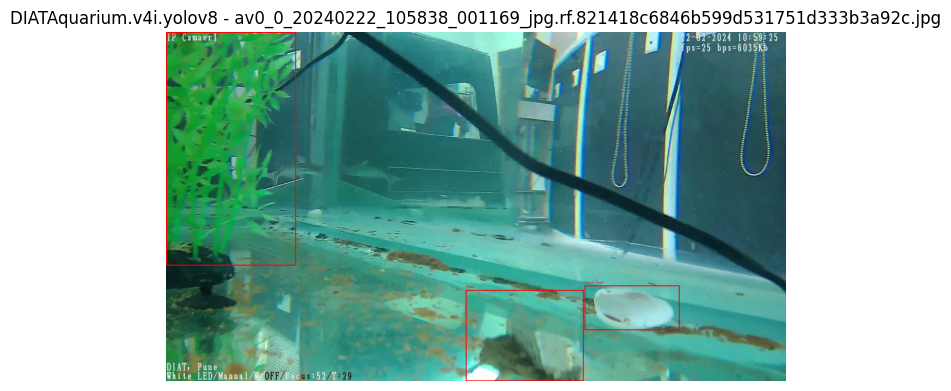

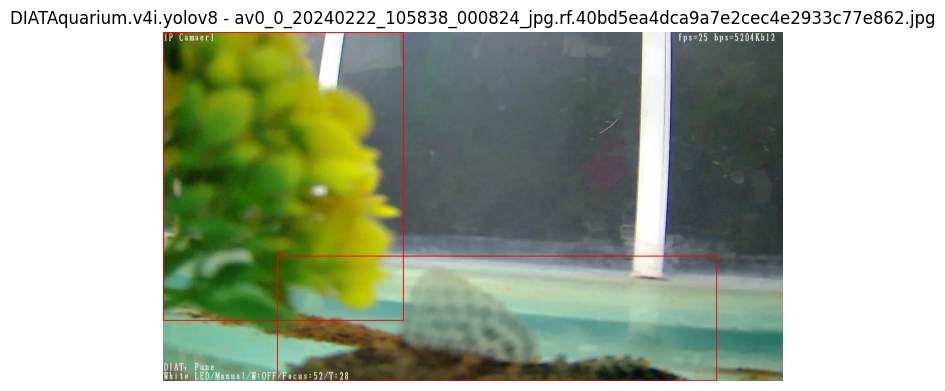

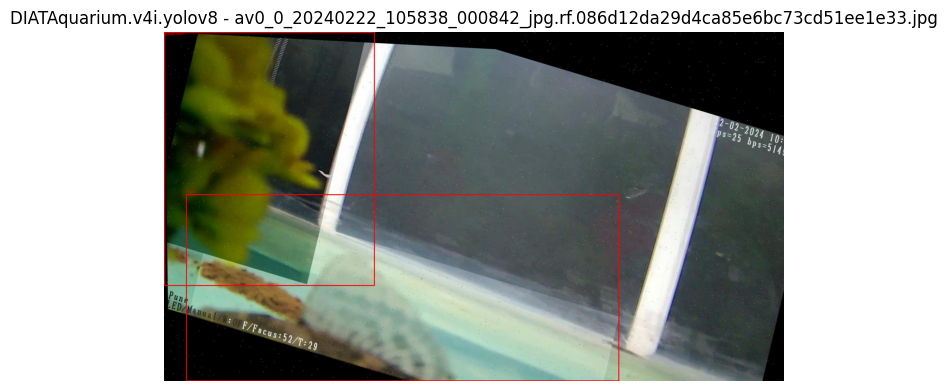


Dataset: Aquatic Plant.v2i.yolov8



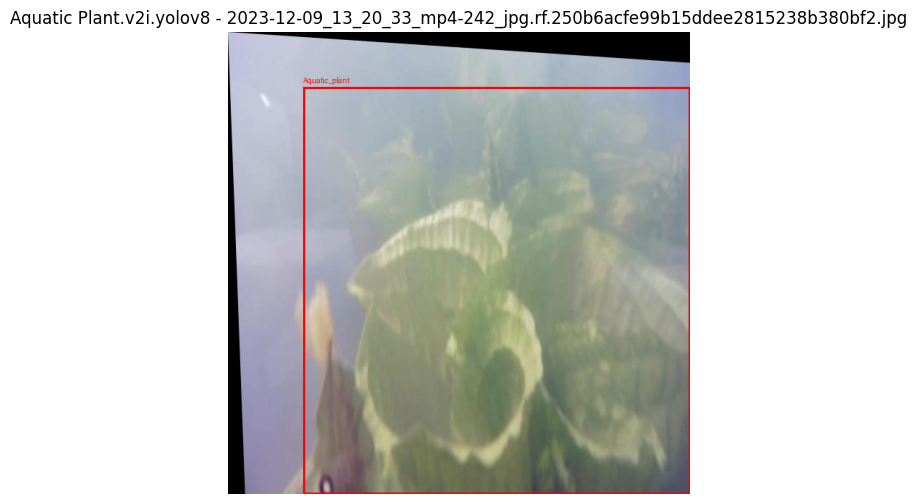

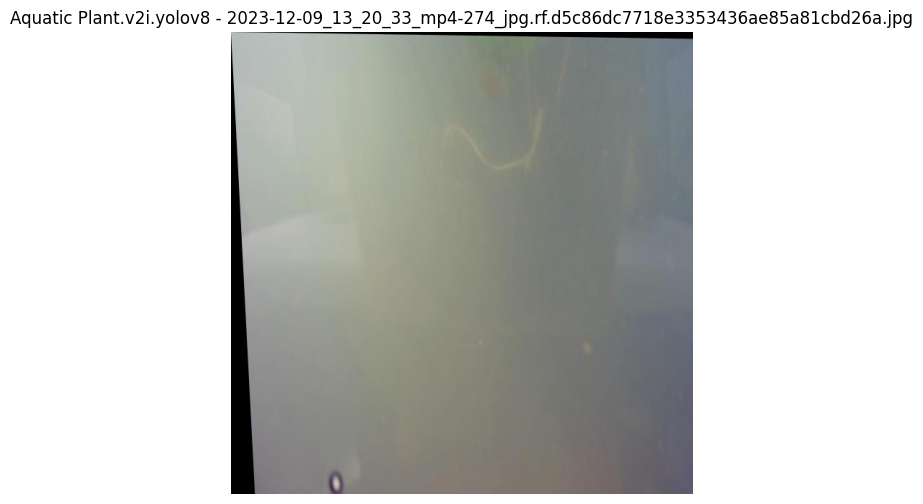

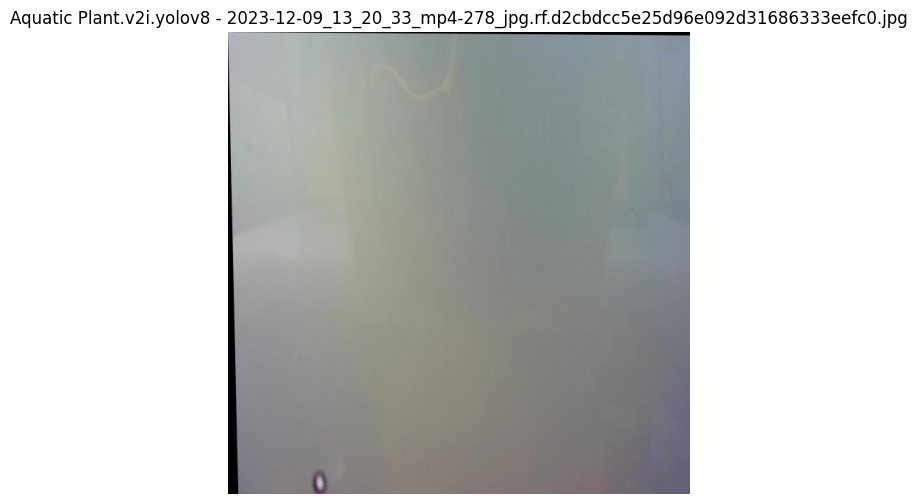


Dataset: well.v8i.yolov8



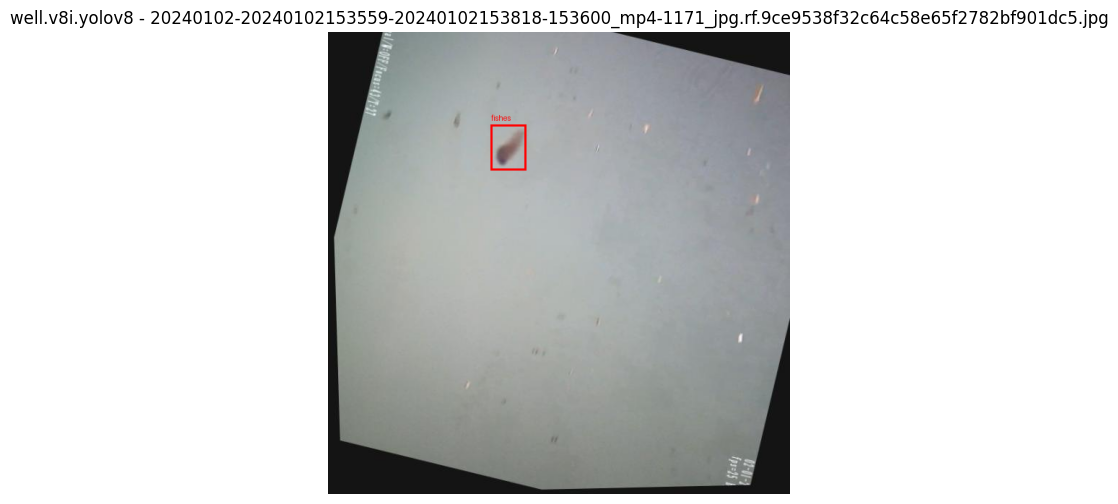

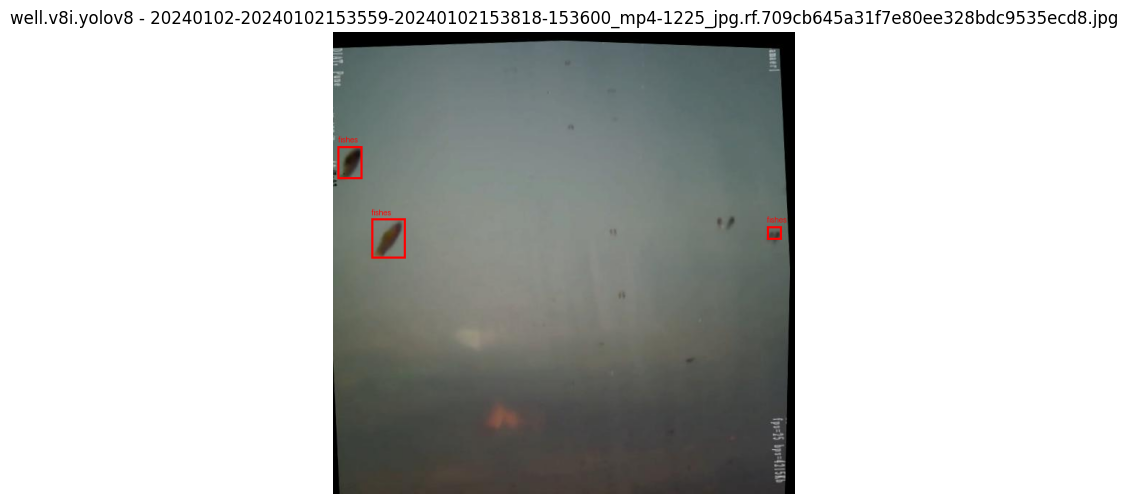

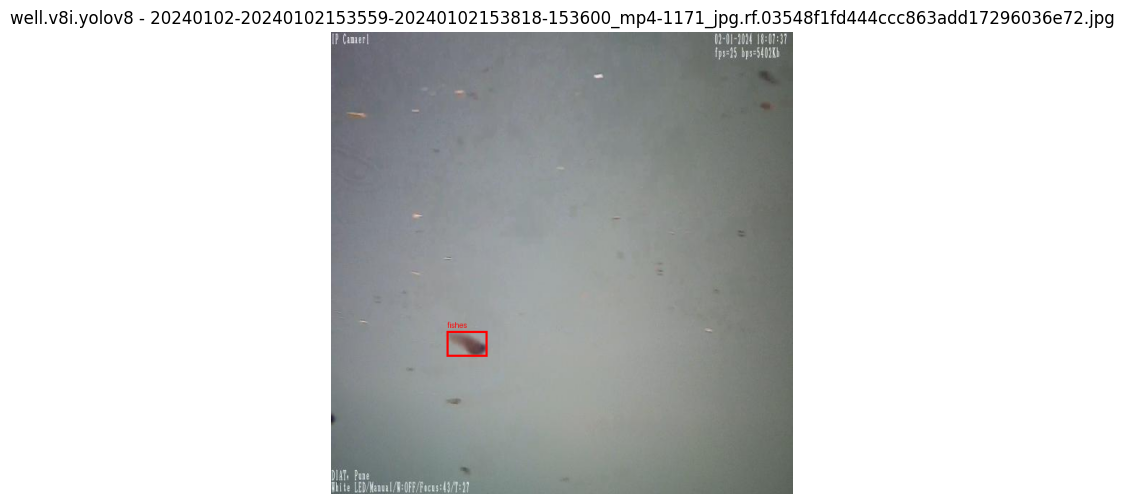

In [ ]:
from PIL import Image, ImageDraw
import os
import random
import matplotlib.pyplot as plt
print("VISUAL ANNOTATION CHECK")
for dataset_name in DATASETS:
    dataset_path = os.path.join(DATASET_FOLDER, dataset_name)
    print()
    print("Dataset:", dataset_name)
    print()
    # Find first available split
    split = "train"
    image_path = os.path.join(dataset_path, split, "images")
    label_path = os.path.join(dataset_path, split, "labels")
    if not os.path.exists(image_path):
        print("Train images not found.")
        continue
    image_files = []
    for entry in os.scandir(image_path):
        if entry.is_file() and entry.name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            image_files.append(entry.name)
        if len(image_files) >= 3:
            break
    # Read class names
    class_names = []
    yaml_path = os.path.join(dataset_path, "data.yaml")
    with open(yaml_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line.startswith("names:"):
                import ast
                class_names = ast.literal_eval(
                    line.split(":", 1)[1].strip()
                )
                break
    for filename in image_files:
        image_file = os.path.join(image_path, filename)
        label_file = os.path.join(
            label_path,
            os.path.splitext(filename)[0] + ".txt"
        )
        try:
            image = Image.open(image_file).convert("RGB")
            draw = ImageDraw.Draw(image)
            width, height = image.size
            if os.path.exists(label_file):
                with open(label_file, "r", encoding="utf-8") as f:
                    lines = f.readlines()

                for line in lines:
                    values = line.strip().split()

                    if len(values) != 5:
                        continue

                    class_id = int(float(values[0]))
                    x_center = float(values[1])
                    y_center = float(values[2])
                    box_width = float(values[3])
                    box_height = float(values[4])

                    x1 = (x_center - box_width / 2) * width
                    y1 = (y_center - box_height / 2) * height
                    x2 = (x_center + box_width / 2) * width
                    y2 = (y_center + box_height / 2) * height

                    draw.rectangle(
                        [x1, y1, x2, y2],
                        outline="red",
                        width=3
                    )

                    if class_id < len(class_names):
                        label = class_names[class_id]
                    else:
                        label = f"class_{class_id}"

                    draw.text(
                        (x1, max(0, y1 - 15)),
                        label,
                        fill="red"
                    )

            plt.figure(figsize=(8, 6))
            plt.imshow(image)
            plt.title(f"{dataset_name} - {filename}")
            plt.axis("off")
            plt.show()

        except Exception as e:
            print("Could not display:", filename, "| Error:", e)

In [ ]:
import os
import shutil
SOURCE = "/content/drive/MyDrive/Dataset (1)"
BACKUP = "/content/drive/MyDrive/raw_backup"
DATASETS = [
    "DIATAquarium.v4i.yolov8",
    "Aquatic Plant.v2i.yolov8",
    "well.v8i.yolov8"
]
os.makedirs(BACKUP, exist_ok=True)
for dataset_name in DATASETS:
    source_path = os.path.join(SOURCE, dataset_name)
    backup_path = os.path.join(BACKUP, dataset_name)

    if os.path.exists(backup_path):
        print(dataset_name, "-> backup already exists")
    else:
        shutil.copytree(source_path, backup_path)
        print(dataset_name, "-> backup created")

print("\nRaw backup location:", BACKUP)

DIATAquarium.v4i.yolov8 -> backup created
Aquatic Plant.v2i.yolov8 -> backup created
well.v8i.yolov8 -> backup created

Raw backup location: /content/drive/MyDrive/raw_backup


In [ ]:
import shutil, os

RAW_BACKUP = "/content/drive/MyDrive/Dataset_RAW_BACKUP"

if not os.path.exists(RAW_BACKUP):
    shutil.copytree(DATASET_FOLDER, RAW_BACKUP)
    print("Backup created at:", RAW_BACKUP)
else:
    print("Backup already exists at:", RAW_BACKUP)

Backup already exists at: /content/drive/MyDrive/Dataset_RAW_BACKUP


In [ ]:
import hashlib, os
def hash_file(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
for dataset in DATASETS:
    print("\nDataset:", dataset)
    for split in ["train", "valid", "test"]:
        img_path = os.path.join(DATASET_FOLDER, dataset, split, "images")
        if not os.path.exists(img_path):
            continue
        files = os.listdir(img_path)[:100]  # sample of 100
        seen = {}
        dupes = 0
        for f in files:
            h = hash_file(os.path.join(img_path, f))
            if h in seen:
                dupes += 1
            else:
                seen[h] = f
        print(f"  {split}: {dupes} duplicate(s) in sample of {len(files)}")


Dataset: DIATAquarium.v4i.yolov8
  train: 0 duplicate(s) in sample of 100
  valid: 0 duplicate(s) in sample of 100

Dataset: Aquatic Plant.v2i.yolov8
  train: 6 duplicate(s) in sample of 100
  valid: 0 duplicate(s) in sample of 100
  test: 0 duplicate(s) in sample of 89

Dataset: well.v8i.yolov8
  train: 0 duplicate(s) in sample of 100
  valid: 0 duplicate(s) in sample of 100
  test: 0 duplicate(s) in sample of 100
